In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#load training data
df = pd.read_csv('../data/raw/train.csv')

#print(df.shape)
#df.head()
#df.info()

In [2]:
#missing value analysis
missing = df.isnull().sum()
missing_percent = (missing / len(df))*100

missing_df = pd.DataFrame({
    'missing_count' : missing,
    'missing_percent' : missing_percent.round(2)
})
#only show columns with missing values, sorted by percentage
missing_df[missing_df['missing_count']>0].sort_values('missing_percent', ascending=False)


,missing_count,missing_percent
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


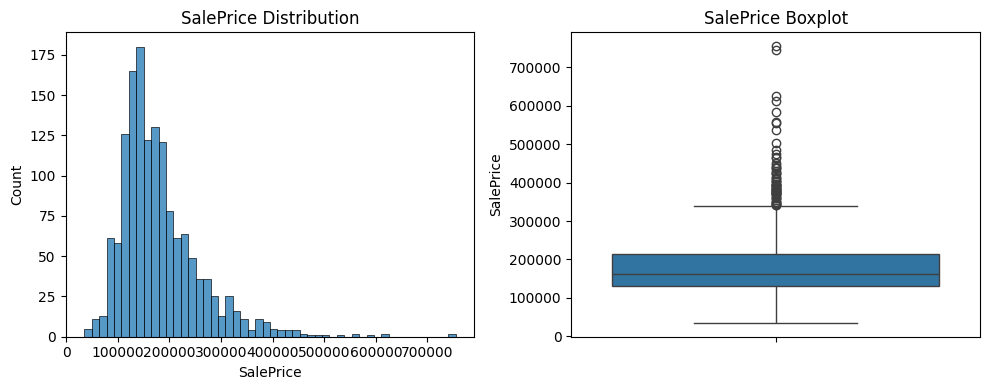

In [3]:
print(df['SalePrice'].describe())

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['SalePrice'],bins=50)
plt.title('SalePrice Distribution')

plt.subplot(1,2,2)
sns.boxplot(y=df['SalePrice'])
plt.title('SalePrice Boxplot')

plt.tight_layout()
plt.savefig('../outputs/01_saleprice_distribution.png')
plt.show()

## Observations
- SalePrice is right skewed → needs log transformation in feature engineering
- Several columns have high missing % → need dropping in cleaning
- Garage columns all missing together → houses with no garage


In [4]:
#get all numercal columns
numerical_cols = df.select_dtypes(include=['number']).columns
print(f"Total numerical columns: {len(numerical_cols)}")
print(numerical_cols)

Total numerical columns: 38
Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')


In [5]:
# correlation of all numerical features with SalePrice
correlation = df[numerical_cols].corr()['SalePrice'].sort_values(ascending=False)
print(correlation)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

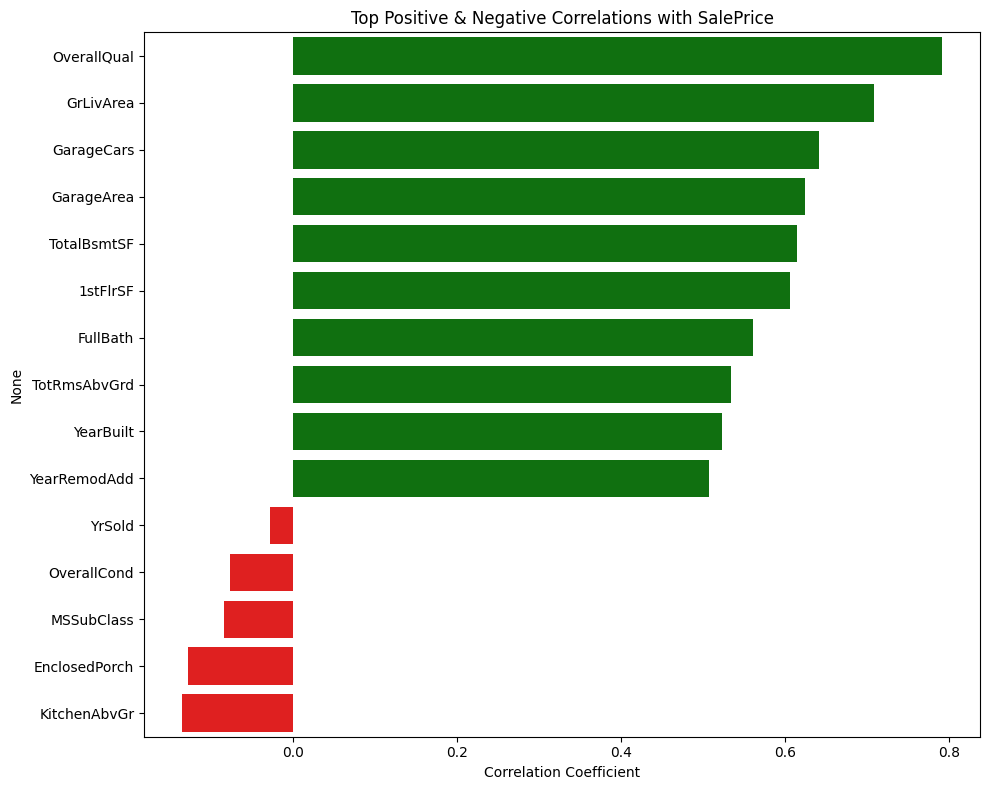

In [ ]:
# visualize positive AND bottom 5 negative correlated features with SalePrice
top_positive = correlation[1:11] # exclude SalePrice itself
top_negative = correlation[-5:]

#combine both
important_corr = pd.concat([top_positive, top_negative])

plt.figure(figsize=(10,8))

colors = ['green' if x>0 else 'red' for x in important_corr.values]

sns.barplot(x=important_corr.values, y=important_corr.index, palette=colors, hue=important_corr.index, legend=False)
plt.title('Top Positive & Negative Correlations with SalePrice')
plt.axvline(x=0, color='black', linewidth=0.8) #vertical line at 0
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.savefig('../outputs/03_correlations.png')
plt.show()

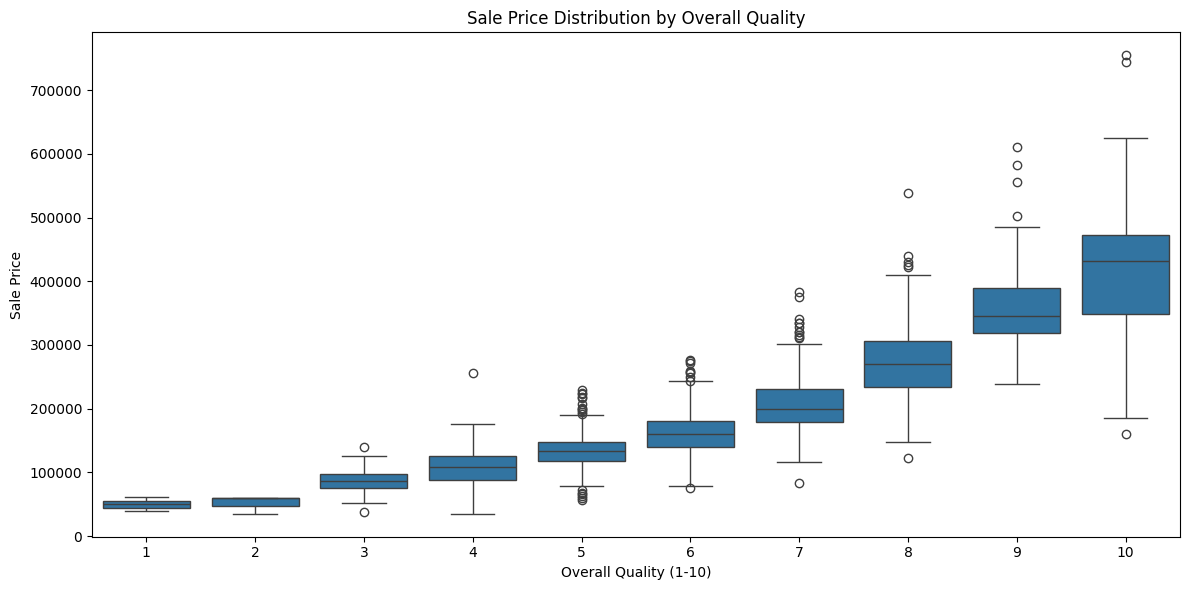

In [10]:
#How does overall quality affect price
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='OverallQual', y='SalePrice')
plt.title('Sale Price Distribution by Overall Quality')
plt.xlabel('Overall Quality (1-10)')
plt.ylabel('Sale Price')
plt.tight_layout()
plt.savefig('../outputs/04_quality_vs_price.png')
plt.show()

In [12]:
#find points having GrLivArea > 4000 and SalePrice < 300000
suspicious = df[(df['GrLivArea']>4000) & (df['SalePrice']<300000)]
print(f"Suspicious points: {len(suspicious)}")
suspicious[['GrLivArea','SalePrice','OverallQual','OverallCond']]

Suspicious points: 2


,GrLivArea,SalePrice,OverallQual,OverallCond
523,4676,184750,10,5
1298,5642,160000,10,5


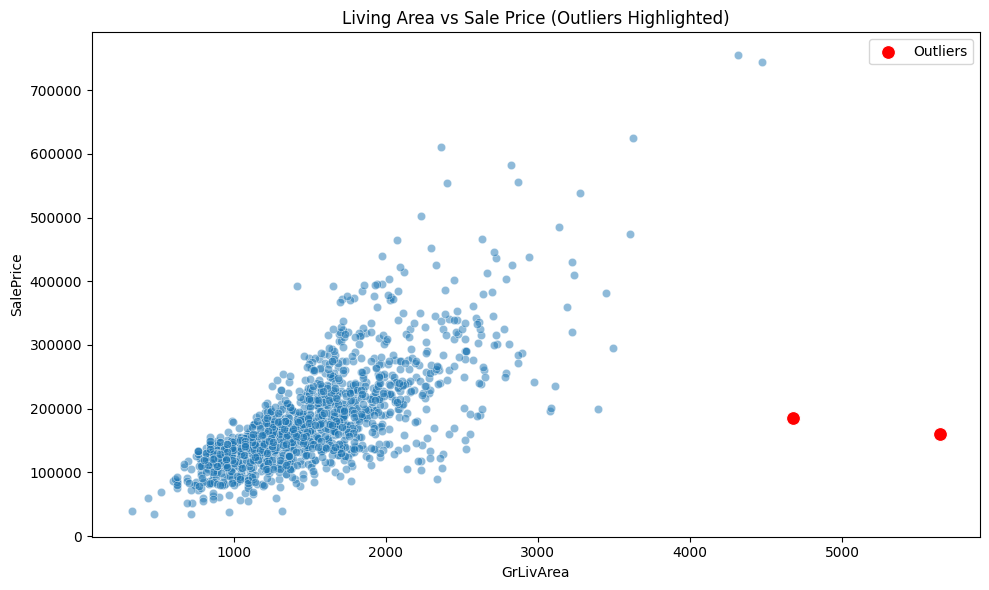

In [13]:
#highlight outliers in red
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='GrLivArea',y='SalePrice',alpha=0.5)
sns.scatterplot(data=suspicious,x='GrLivArea',y='SalePrice',color='red',s=100,label='Outliers') #s is the size of dots
plt.title('Living Area vs Sale Price (Outliers Highlighted)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/05_livarea_outliers.png')
plt.show()

## Categorical Features

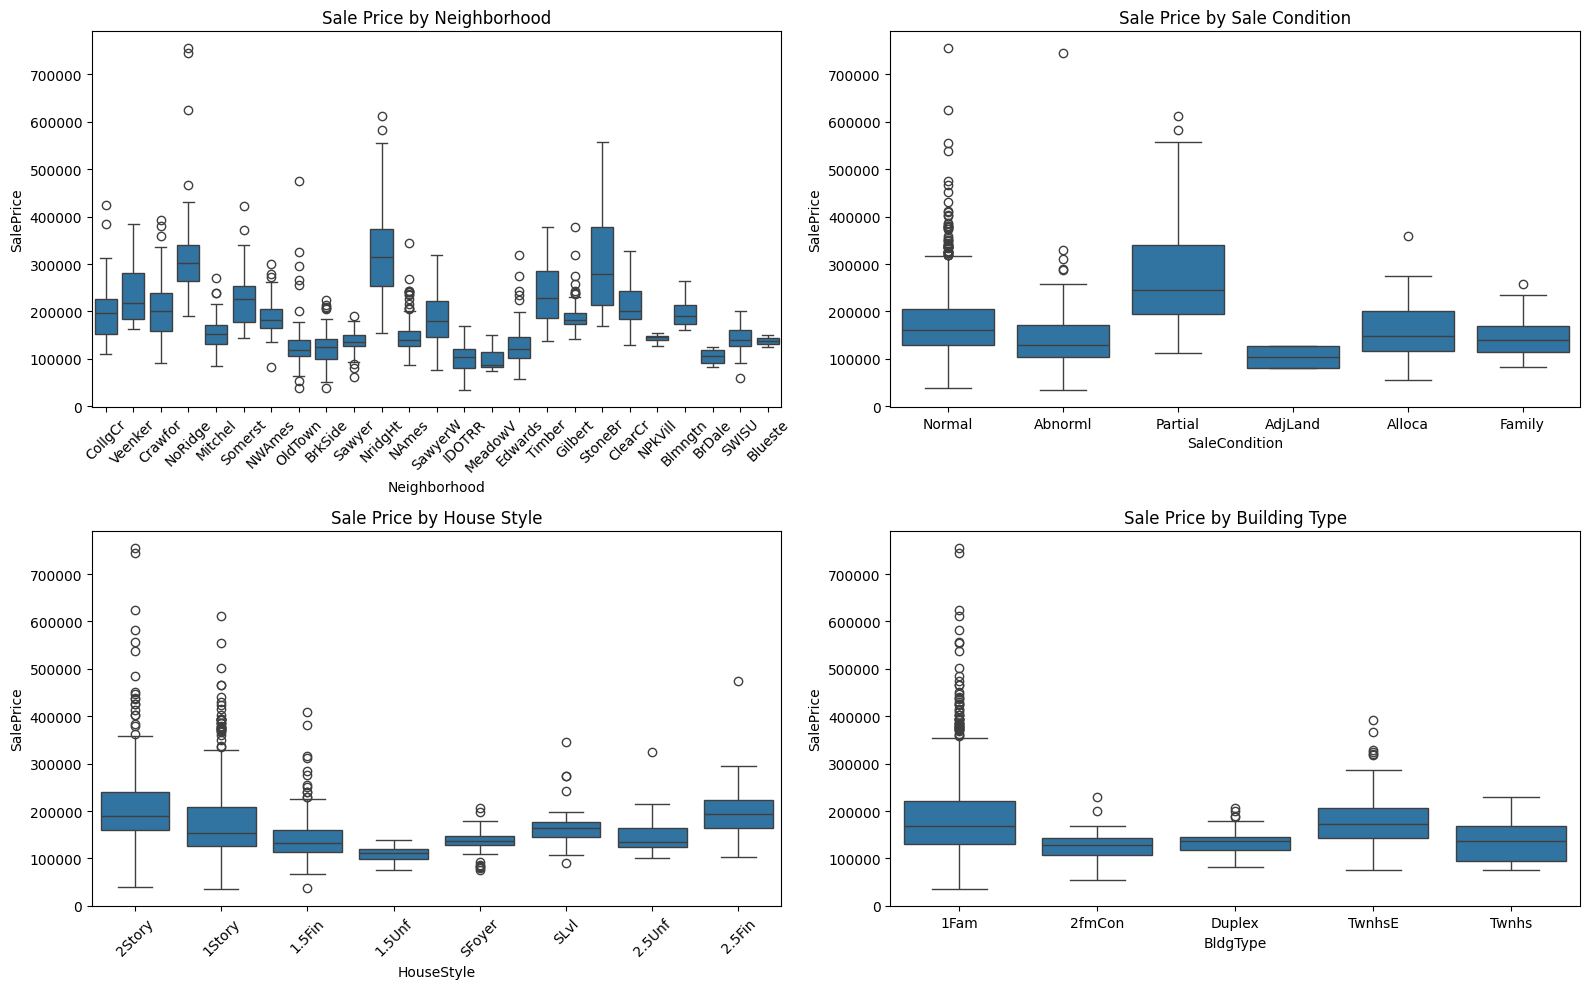

In [14]:
fig, axes = plt.subplots(2,2, figsize=(16,10))

#Plot1: Neighbourhood vs Price
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', ax=axes[0,0])
axes[0,0].set_title('Sale Price by Neighborhood')
axes[0,0].tick_params(axis='x', rotation=45) #rotate x labels for better visibility

#Plot 2: Sale Condition vs Price
sns.boxplot(data=df, x='SaleCondition', y='SalePrice', ax=axes[0,1])
axes[0,1].set_title('Sale Price by Sale Condition')

#Plot 3: House Style vs Price
sns.boxplot(data=df, x='HouseStyle', y='SalePrice', ax=axes[1,0])
axes[1,0].set_title('Sale Price by House Style')
axes[1,0].tick_params(axis='x', rotation=45) #rotate x labels for better visibility

#Plot 4: Building Type vs Price
sns.boxplot(data=df, x='BldgType', y='SalePrice', ax=axes[1,1])
axes[1,1].set_title('Sale Price by Building Type')

plt.tight_layout()
plt.savefig('../outputs/06_categorical_analysis.png')
plt.show()

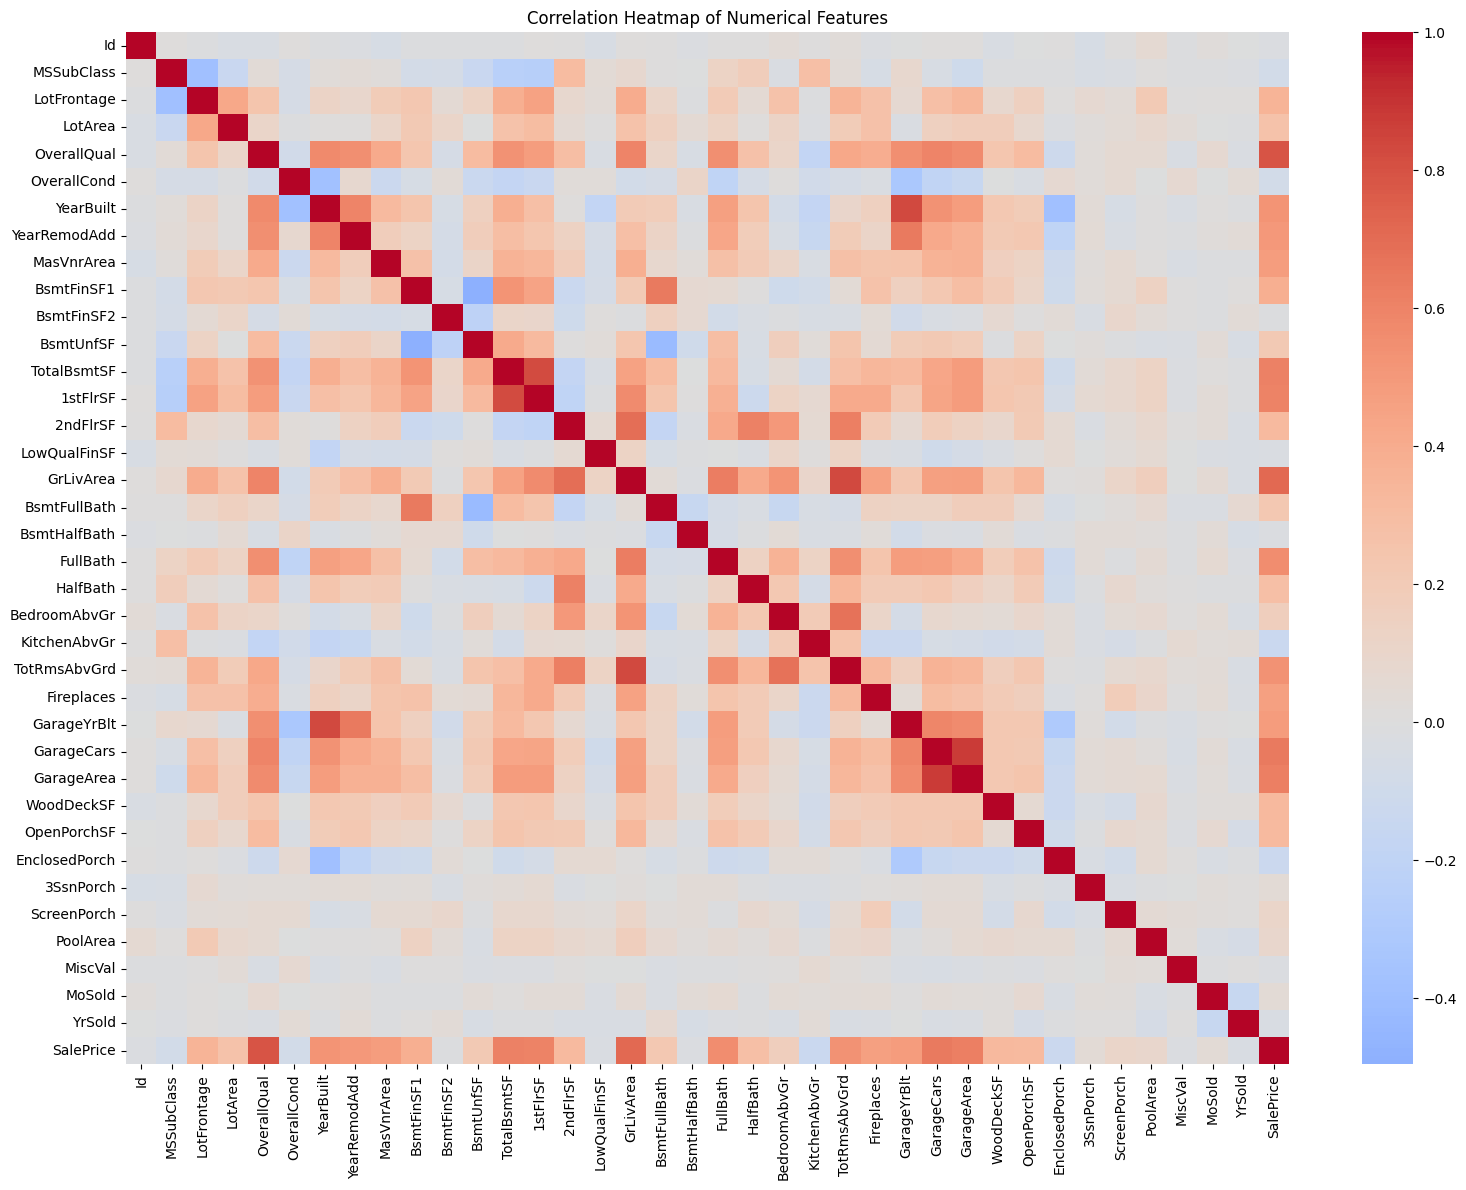

In [15]:
#correlation heatmap

plt.figure(figsize=(16,12))
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix,
            cmap='coolwarm',
            center=0,
            annot=False)

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout() 
plt.savefig('../outputs/07_correlation_heatmap.png')
plt.show()

## EDA Summary & Action Items

### Missing Values
- Drop: PoolQC, MiscFeature, Alley, Fence, MasVnrType (>50% missing)
- Fill numerical with median: LotFrontage, GarageYrBlt, MasVnrArea
- Fill categorical with None/mode: Garage*, Bsmt*, Electrical

### Outliers
- Remove 2 suspicious houses (GrLivArea > 4000, SalePrice < 300000)

### Transformations Needed
- Log transform SalePrice (right skewed)
- Log transform skewed features

### Important Features
- OverallQual (0.79 correlation)
- GrLivArea (0.71 correlation)
- Neighborhood (huge price variation)